## This project required the analysis of Stock Performance using Clustering Algorithms.  Here, I built a function to assist with the analysis of outliers which allowed me to bi- or tri-sect the data and then automatically graph the divided data groups.  This practice quickly makes the outliers apparent.

## Additionally I include a function that I used to rapidly construct graphics of data resulting from any groupby selection of choice.

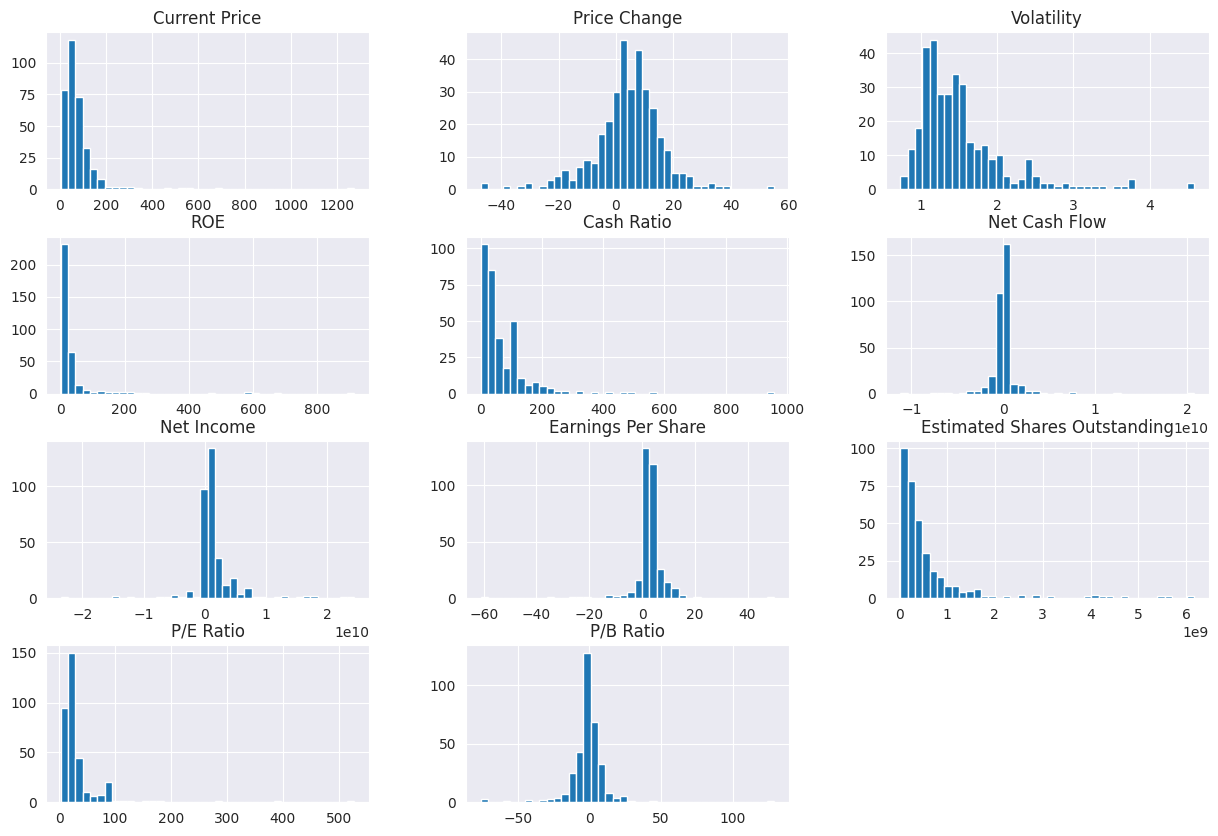

In [ ]:
'''UNMODIFIED GRAPHS   Notice that there are large swaths of x-axis space that looks empty'''
sns.set_style("darkgrid")                       # fills graph backgrounds
data.hist(figsize=(15, 10), bins=40)            # contrsucts histogram of all numeric plots of all data in the dataframe
plt.show()                                      # draws the plot

In [ ]:
def weedkiller(dframe, colindex, lim1, lim2=0, *, fixbins=30):              # bi- or trifercates data into smaller segments for graphical examination
  '''In datasets with long tails or scattered ouliers, it becomes difficult to see the outliers because they are lost in the scale of the graph
  because of the hihger peaks in the data.  I built this function to rapidly segment a dataset before graphing so you can see the outliers more
  clearly.  When data disapears into background noise, we would say we lost the signal in the weeds.  Thus the name of the function: weedkiller'''
  lower, mid, upper = pd.DataFrame(), pd.DataFrame(), pd.DataFrame()        # defines working dataframes within the function
  lower = dframe[dframe[colindex]<lim1]                                     # assignes the first data segment using the passed limit value
  if lim2==0:                                                               # divides the graphing task based on the number of divisions
    fig,((gf1, gf2)) = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))      # assigns a subplot frame based on 2 plots
    lim2=lim1                                                               # assignes the value of the defined limitor to the undefined limitor
    upper = dframe[dframe[colindex]>=lim1]                                  # creates a second data segment using the passed limit value
  else:
    fig,((gf1, gf3, gf2)) = plt.subplots(nrows=1, ncols=3, figsize=(16, 6), layout='constrained')               # if the data is to be trifurcated defines the appropriate suboplot
    mid = dframe[(dframe[colindex]>=lim1) & (dframe[colindex]<=lim2)]       # assinges the middling data to another dataframe
    upper = dframe[dframe[colindex]>=lim2]                                  # assinges the upper data to another dataframe
    sns.histplot(ax = gf3, data=mid[colindex], bins=fixbins)                # because the middling data is unique to this circumstance the histrogram is defined here
    gf3.set_title(f'Data Segment of {colindex} values greater than {lim1} but less than {lim2}', fontsize=10)   # along with its title
  sns.histplot(ax = gf1, data=lower[colindex], bins=fixbins)                # definition of the histogram plotting the lower data
  gf1.set_title(f'Data Segment of {colindex} values less than {lim1}')      # with its title
  sns.histplot(ax = gf2, data=upper[colindex], bins=fixbins)                # definition of the histogram plotting the upper data
  gf2.set_title(f'Data Segment of {colindex} values greater than {lim2}')   # with its title
  plt.xlabel(f'{colindex}')                                                 # labels the x-axis
  plt.tight_layout()                                                        # tidies up the graphs
  plt.show()                                                                # draws the plot

## This is the bifurcated output from the weedkiller function ... Compare this to the first graph in the series depicted above (Current Price).

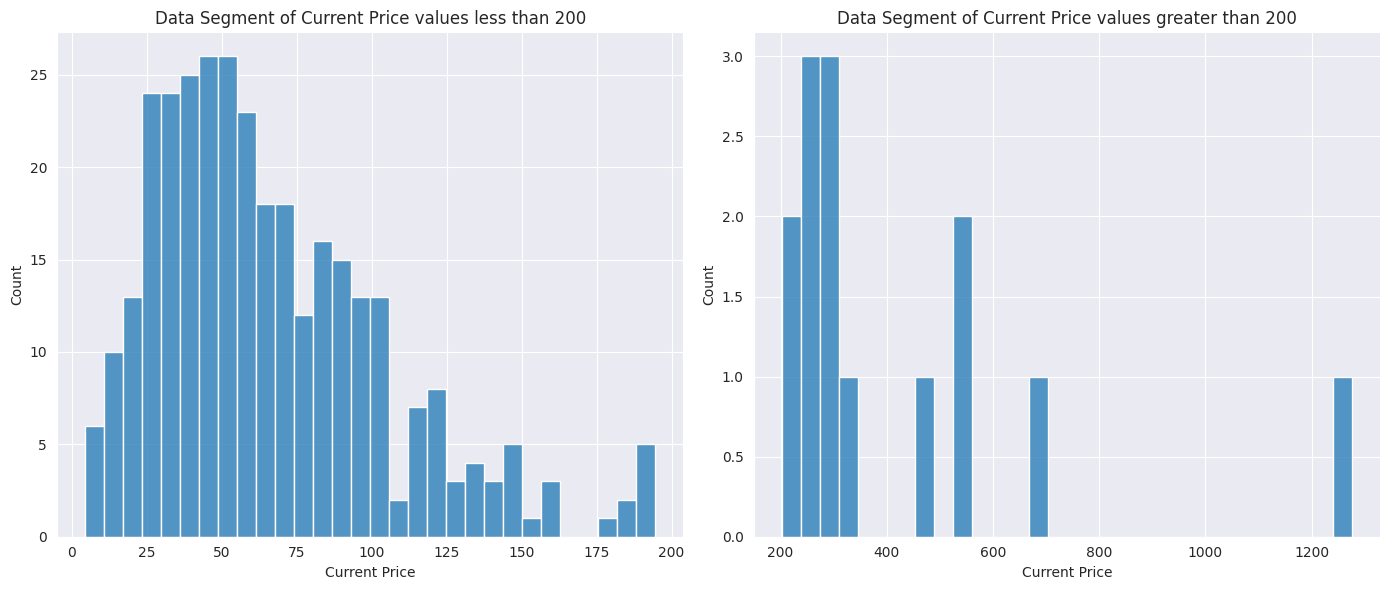

In [ ]:
weedkiller(data, 'Current Price', 200)

## Again, from the same function, an example of trifurcated data.  All that is required for the additional functionality is the inclusion of a second value in the function call.  Compare this to the second graph in the original series depicted above (Price Change).

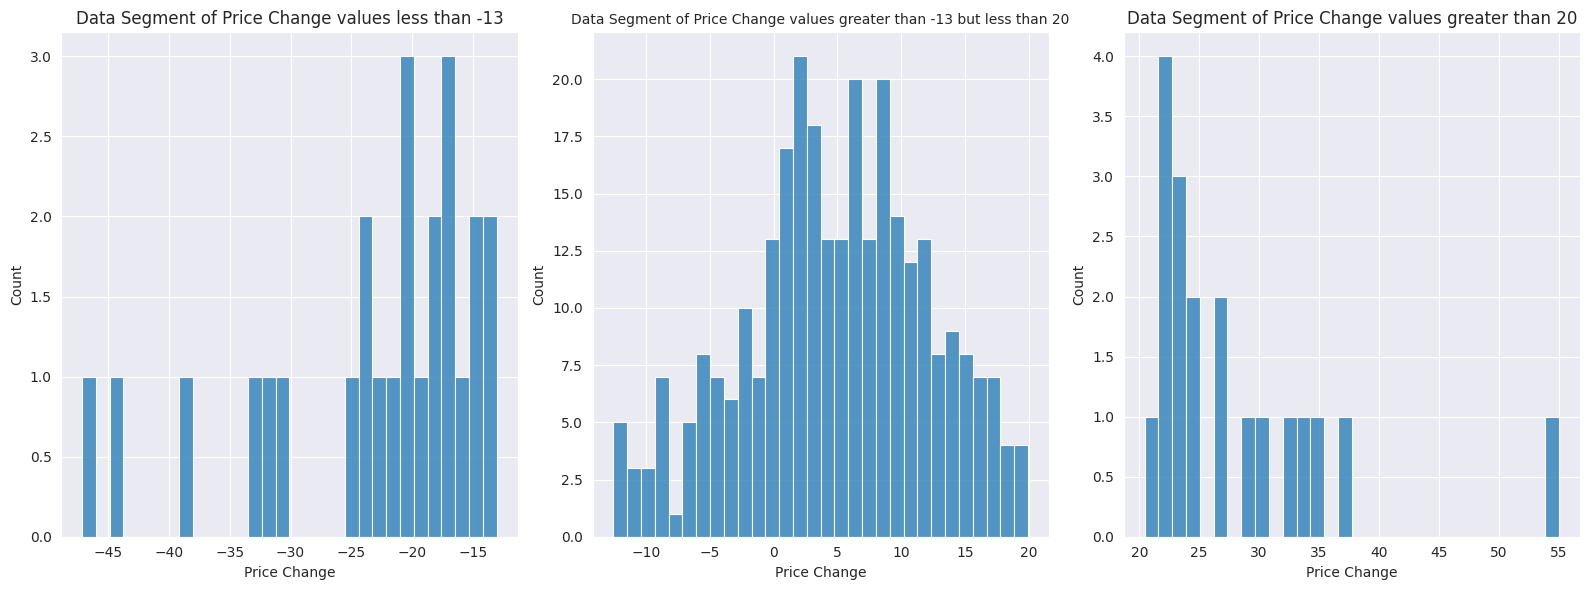

In [ ]:
weedkiller(data, 'Price Change', -13, 20)

## This next function, built in the same project, automates groupby choices for Exploratory Data Analysis. Combined with a simple loop shown in the following cell, it automates the pairwise analysis of all the numerical data. While the function's complexity is not needed for the particular operation shown, it is a single piece of code that can accommodate several different combinations of user preferences for data visualization.

In [ ]:
def groupie(source, this, that, *, method='vc', perc=False, sort=True):   # function building groupby objects and graphing the data
  if method=='vc' and sort==True:                                         # supports the user's chioce of a Value Count analysis with sorting of the results)
    intgb = source.groupby(this)[that].value_counts().sort_values()       # groupby opperation using requested columns by Value Count
    plt.title(f'Amounts of Each {that} for Each {this}')                  # adds a Title to the plot
  elif method=='vc' and sort==False:                                      # supports the user's chioce of a Value Count analysis without sorting)
    intgb = source.groupby(this)[that].value_counts()                     # groupby opperation using requested columns by Value Count
    plt.title(f'Amounts of Each {that} for Each {this}')                  # adds a Title to the plot
  elif method=='av' and sort==True:                                       # supports the user's chioce of a AVerage analysis with sorting of the results)
    plt.title(f'Average {that} for Each {this}')                          # adds a Title to the plot
    intgb = source.groupby(this)[that].mean().sort_values()               # groupby opperation using requested columns and averaging the data groups
  else:
    intgb = source.groupby(this)[that].mean()                             # supports the user's chioce of a AVerage analysis without sorting)
    plt.title(f'Average {that} for Each {this}')                          # adds a Title to the plot
  intdf = pd.DataFrame(intgb)                                     # converstion of the groupby object to a DataFrame
  intdf = intdf.reset_index(drop=False)                           # resets the index of the dataframe
  if perc==False and method=='vc':                                # this if statment directs use of the normalization function to normalize unbalanced data
    sns.barplot(data=intdf, x=this, y='count', hue=that)          # outlines a barplot of the data from the groupby catagories using counts
    plt.ylabel('Count')                                           # adds y-axis labels
  elif perc==False and method=='av':
    sns.barplot(data=intdf, x=this, y=that)                       # outlines a barplot of the data from the groupby catagories using averages
    plt.ylabel(f'Average {that}')                                 # adds y-axis labels
  else:
    intdf['percentage'] = intdf.groupby(level=0)['count'].transform(lambda x: round(100 * x / x.sum(), 1)) # adds the percentage column to normalize the data
    sns.barplot(data=intdf, x=this, y='percentage', hue=that)     # outlines a barplot of the data from the groupby catagories using percentages
    plt.ylabel('Percentage')                                      # adds y-axis labels
  plt.setp(plt.gca().get_xticklabels(), rotation=-45, ha="left")  # rotates the brand names by 45 degrees so they all fit legibly
  plt.xlabel(f'{this}')                                           # adds x-axis labels
  plt.show();                                                     # draws the plot

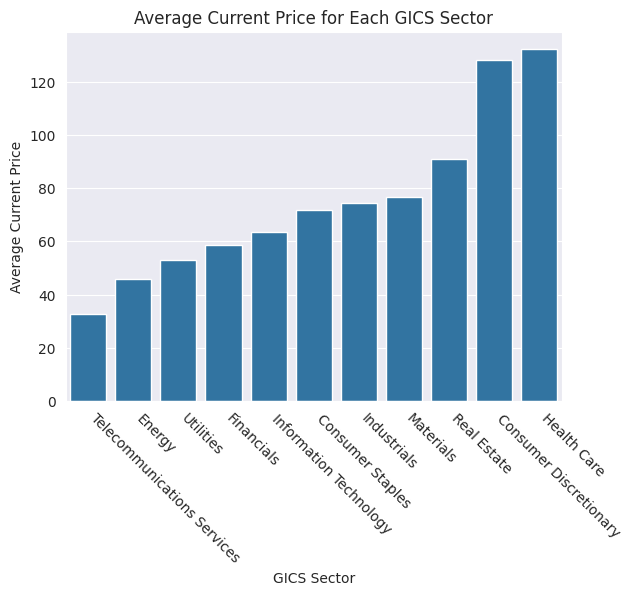

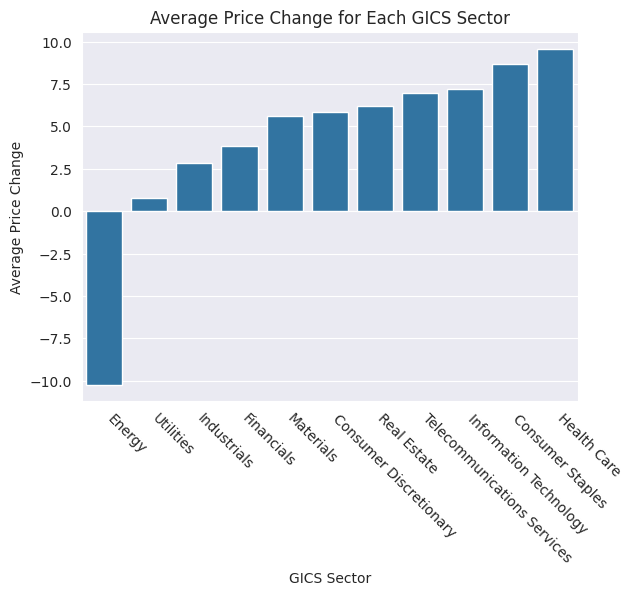

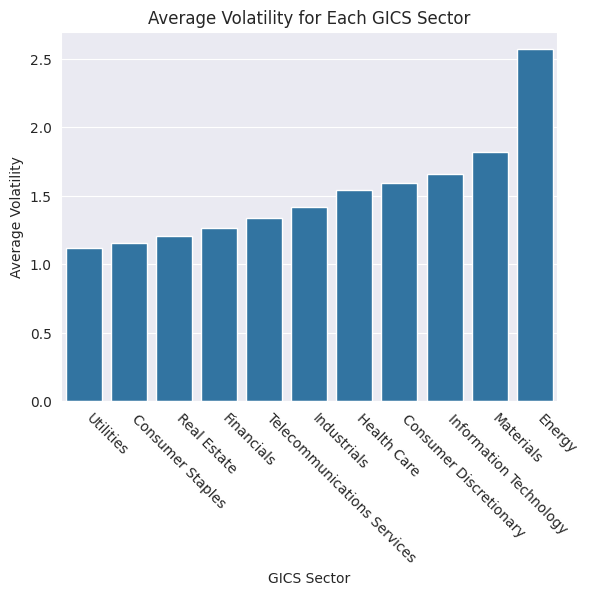

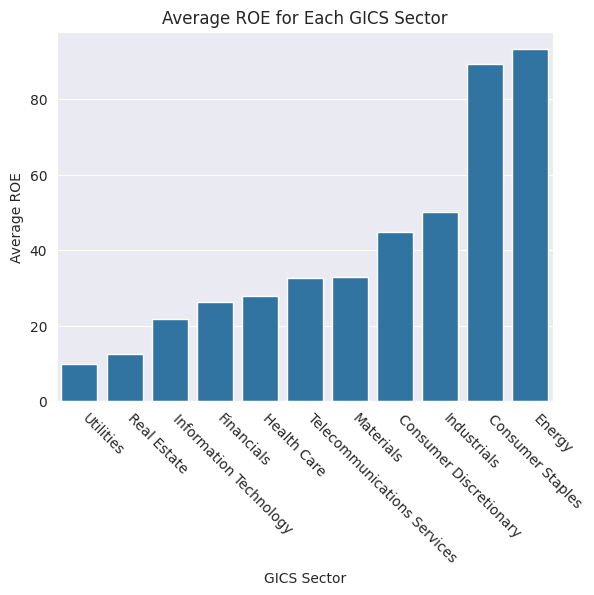

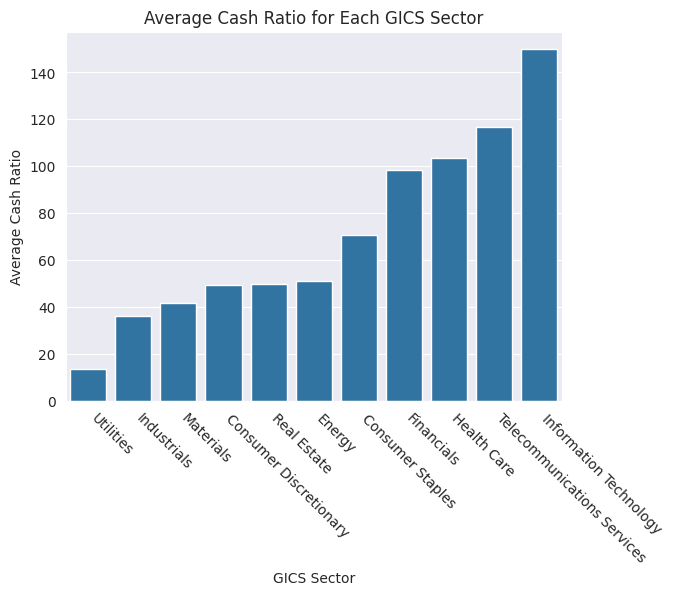

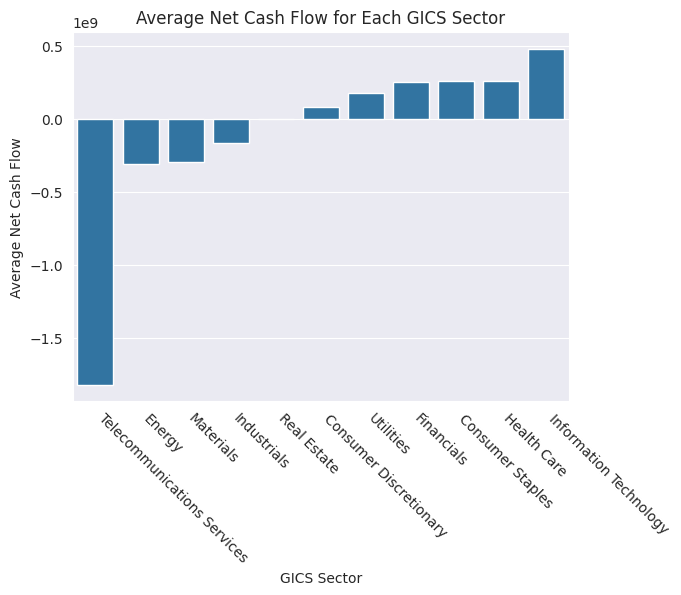

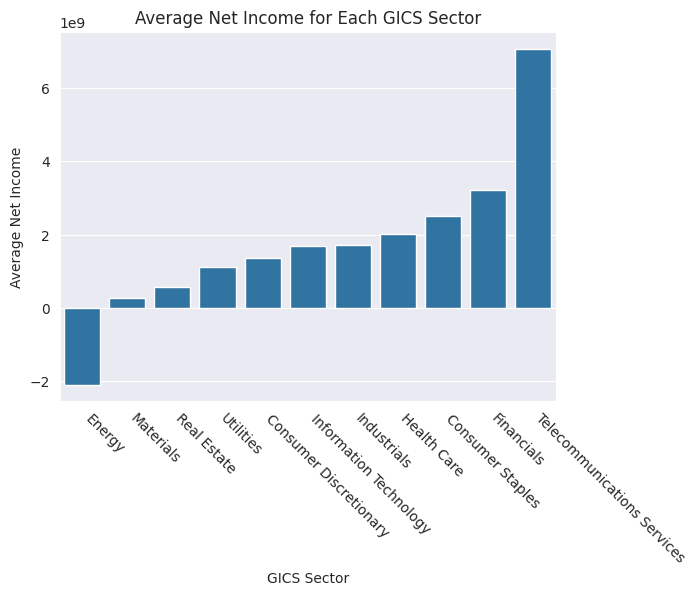

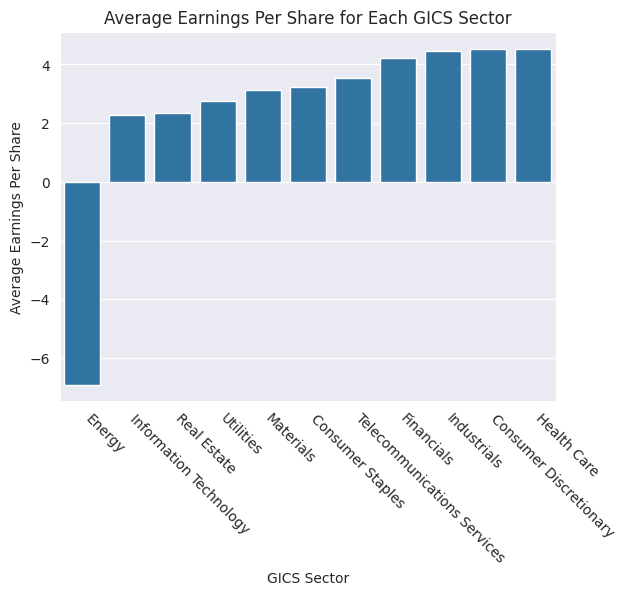

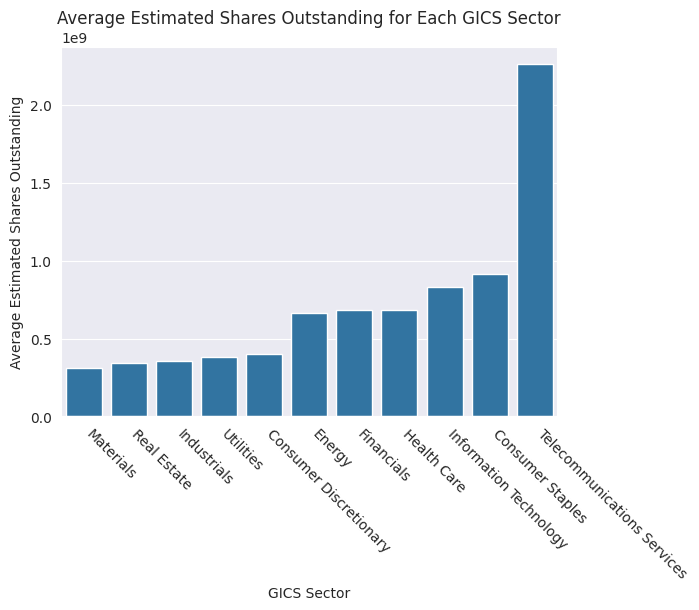

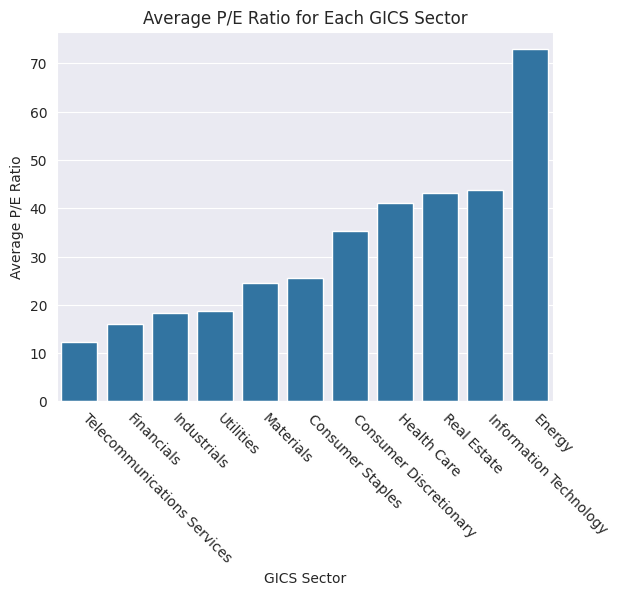

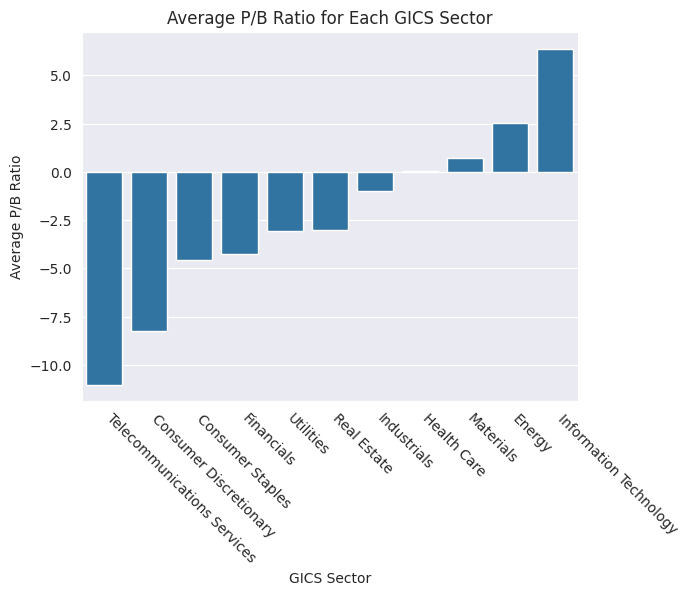

In [ ]:
numvar = ['Current Price', 'Price Change', 'Volatility', 'ROE',
          'Cash Ratio', 'Net Cash Flow', 'Net Income',
          'Earnings Per Share', 'Estimated Shares Outstanding',
          'P/E Ratio', 'P/B Ratio']
for i in numvar:                                        # iterates though all numeric variable names and...
  groupie(data, 'GICS Sector', i, method='av')          # plots histograms grouped by each Market Segment